In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [3]:
dataset=pd.read_csv('Student_Performance.csv')

In [4]:
dataset.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
dataset.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [6]:
dataset['Extracurricular Activities'].value_counts()

Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64

In [7]:
dataset['Extracurricular Activities'].dtype

dtype('O')

In [8]:
dataset['Extracurricular Activities'].astype('str')

0       Yes
1        No
2       Yes
3       Yes
4        No
       ... 
9995    Yes
9996    Yes
9997    Yes
9998    Yes
9999     No
Name: Extracurricular Activities, Length: 10000, dtype: object

In [9]:
dataset['Extracurricular Activities'] = dataset['Extracurricular Activities'].map({
    'Yes': 1,
    'No': 0
})


In [10]:
dataset['Extracurricular Activities']

0       1
1       0
2       1
3       1
4       0
       ..
9995    1
9996    1
9997    1
9998    1
9999    0
Name: Extracurricular Activities, Length: 10000, dtype: int64

In [11]:
dataset.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


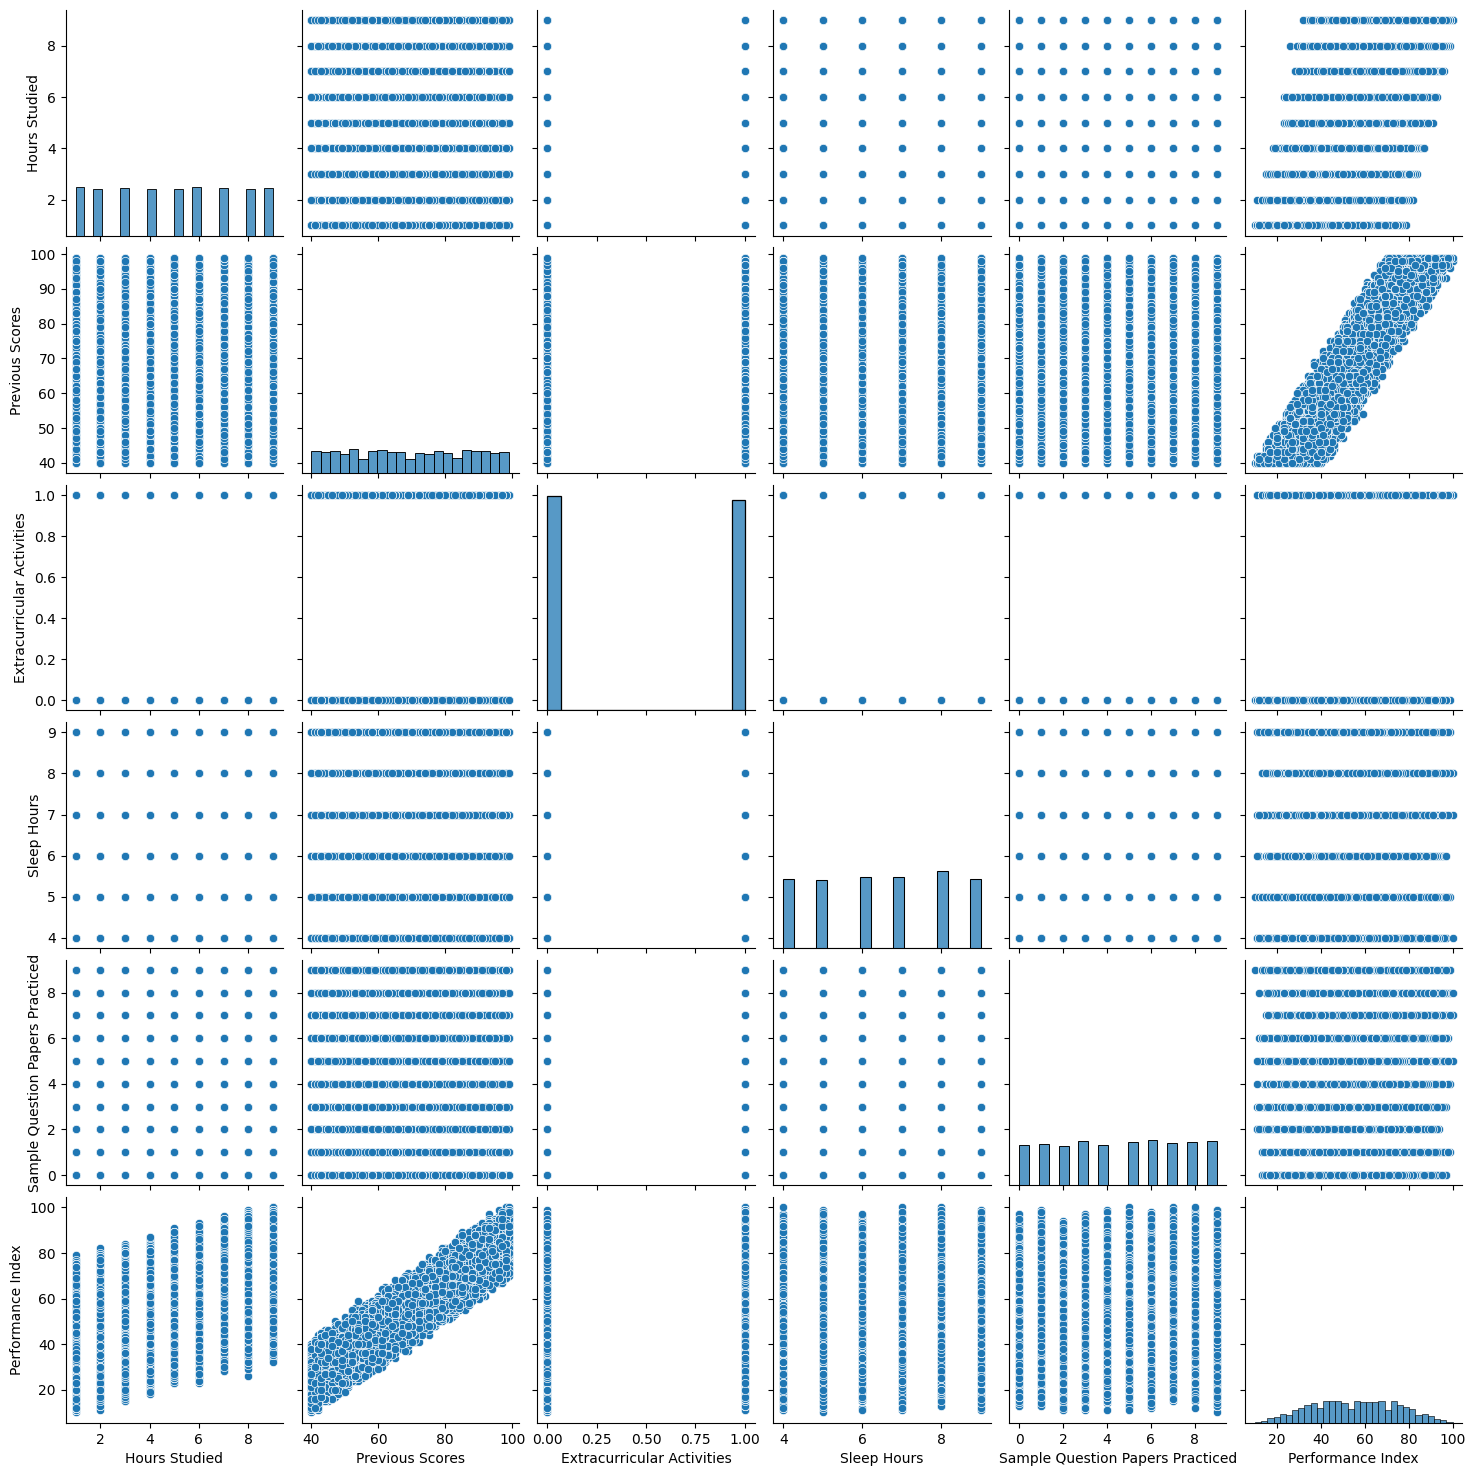

In [12]:
sns.pairplot(dataset)

In [13]:
X=dataset.iloc[:,:-1]

In [14]:
y=dataset.iloc[:,-1]

In [15]:
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [16]:
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [18]:
X_train

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
4901,5,49,0,5,5
4375,7,88,1,4,9
6698,3,94,1,7,1
9805,9,54,1,5,9
1101,4,56,1,8,6
...,...,...,...,...,...
5734,8,50,1,6,6
5191,4,68,0,9,3
5390,9,48,0,7,6
860,1,47,0,9,0


In [19]:
y_train

4901    33.0
4375    82.0
6698    74.0
9805    49.0
1101    43.0
        ... 
5734    48.0
5191    51.0
5390    44.0
860     20.0
7270    24.0
Name: Performance Index, Length: 7500, dtype: float64

In [20]:
#Standardize
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [21]:
X_train

array([[ 0.00796272, -1.19062085, -0.98912579, -0.90874945,  0.13314392],
       [ 0.77854894,  1.05902612,  1.01099376, -1.49731775,  1.53122497],
       [-0.76262349,  1.40512565,  1.01099376,  0.26838714, -1.26493713],
       ...,
       [ 1.54913515, -1.24830411, -0.98912579,  0.26838714,  0.48266418],
       [-1.5332097 , -1.30598737, -0.98912579,  1.44552374, -1.6144574 ],
       [-1.14791659, -1.36367062, -0.98912579, -0.32018115,  0.48266418]],
      shape=(7500, 5))

In [22]:
X_test

array([[-0.01307435,  0.00802406, -0.99123838,  0.89573425, -0.85886197],
       [-1.18042744, -1.31779058,  1.00883906, -1.47770044,  1.22238674],
       [ 0.76516103, -0.74134943,  1.00883906,  0.30237558,  0.18176239],
       ...,
       [-0.01307435,  0.69975344, -0.99123838,  0.89573425,  1.22238674],
       [-0.40219205,  0.1809564 , -0.99123838, -0.88434176, -0.51198718],
       [ 1.15427873, -0.39548474,  1.00883906, -1.47770044, -0.85886197]],
      shape=(2500, 5))

In [23]:
regression=LinearRegression()
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
print('Coefficent:',regression.coef_)
print('intercept:',regression.intercept_)

Coefficent: [ 7.40973867 17.62000334  0.29183721  0.81024328  0.54624431]
intercept: 55.41839999999999


In [25]:
y_predicted=regression.predict(X_test)

In [26]:
y_predicted

array([55.43024038, 23.21710852, 48.66416509, ..., 68.75538458,
       54.34123218, 55.63083271], shape=(2500,))

In [28]:
print(mean_squared_error(y_test,y_predicted))
print(mean_absolute_error(y_test,y_predicted))
print(root_mean_squared_error(y_test,y_predicted))
score=r2_score(y_test,y_predicted)
print(score)
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

4.636837605606022
1.7239573815343698
2.15333174536717
0.9874149336820424
0.9873897029957593


In [ ]:
dataset.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


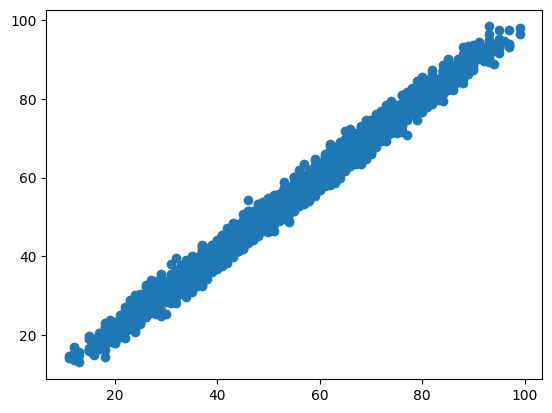

In [30]:
plt.scatter(y_test,y_predicted)

In [31]:
errors=y_test-y_predicted
print(errors)

6252   -4.430240
4684   -3.217109
1731   -2.664165
4742   -4.042017
4521   -2.780583
          ...   
4862   -0.123165
7025   -1.614966
7647    1.244615
7161    1.658768
73     -3.630833
Name: Performance Index, Length: 2500, dtype: float64


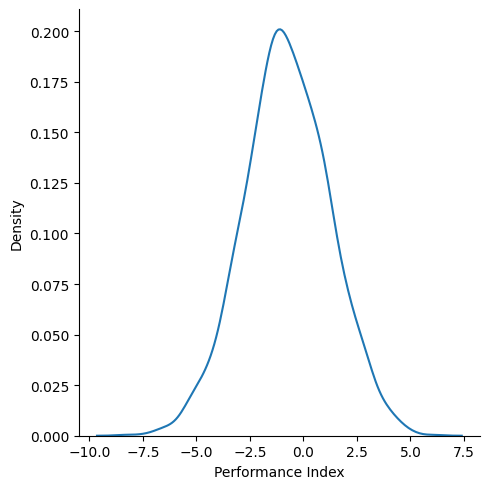

In [33]:
sns.displot(errors,kind='kde')

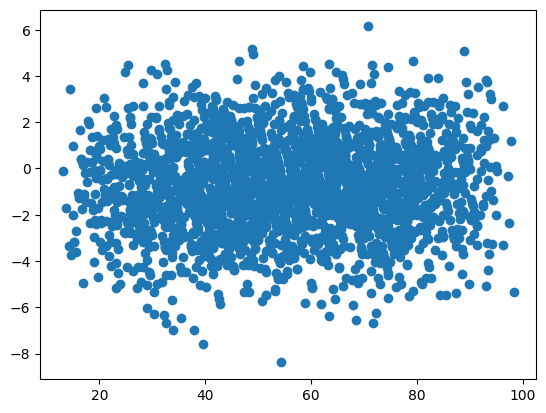

In [34]:
plt.scatter(y_predicted,errors)

In [37]:
dataset

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [42]:
hoursStudied=int(input('Enter Hours Studied: '))
previousScore=int(input('Enter Previous Score: '))
ExtraActivities=int(input('Enter 1 if Yes, 0 if N0: '))
sleepHours=int(input('Enter Sleep Hours: '))
sampleQuestions=int(input('Enter Sample Question Papers Practiced: '))
arr=[[hoursStudied,previousScore,ExtraActivities,sleepHours,sampleQuestions]]
userInput=scaler.fit_transform(arr)
print('Your performance Index is: ',regression.predict(userInput))


Your performance Index is:  [55.4184]


In [35]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [36]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:      Performance Index   R-squared (uncentered):                   0.106
Model:                            OLS   Adj. R-squared (uncentered):              0.105
Method:                 Least Squares   F-statistic:                              177.9
Date:                Mon, 12 Jan 2026   Prob (F-statistic):                   1.85e-179
Time:                        22:52:22   Log-Likelihood:                         -40759.
No. Observations:                7500   AIC:                                  8.153e+04
Df Residuals:                    7495   BIC:                                  8.156e+04
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             7.4097      0.641     11.565      0.000       6.154       8.666
x2            17.6200      0.641     27.505      0.000      16.364      18.876
x3             0.2918      0.641      0.455      0.649      -0.964       1.548
x4             0.8102      0.641      1.265      0.206      -0.446       2.066
x5             0.5462      0.641      0.853      0.394      -0.710       1.802
==============================================================================
Omnibus:                        4.365   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.113   Jarque-Bera (JB):                4.584
Skew:                           0.024   Prob(JB):                        0.101
Kurtosis:                       3.111   Cond. No.                         1.03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""